# Design Effectiveness — Demographic Balance of Control vs Test
**Vanguard A/B test · Week 5 · Diana & Zidene**

**Goal —** before comparing UX performance (error & completion rates), confirm the Control and Test groups are *demographically balanced*. If age, tenure or gender differ systematically between groups, any KPI gap could be driven by *who* the clients are rather than by the new interface.

**Pipeline**
1. Load the cleaned demographic file and the experiment-group file; merge on `client_id`.
2. Label clients with no assigned group as `no_data` and decide how to treat them.
3. Restrict to the primary population (`Control` / `Test`) and check balance on **age**, **tenure** and **gender**.
4. Conclude which segments are comparable enough to carry into the KPI analysis.

> 🤖 *Overview block proposed by assistant — review and reword in your own voice.*

## 1. Load data & build the analysis dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import sys

%matplotlib inline


In [2]:
#importing the final merged file to use for analysis
import pandas as pd
clients_df=pd.read_csv("../data/clean/clean_final_demo.csv", sep=None, engine="python")
df0=clients_df.copy()
display(df0.head(2))
display(df0.info())

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.3,6.0,9.0


<class 'pandas.DataFrame'>
RangeIndex: 70595 entries, 0 to 70594
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70595 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70595 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


None

In [3]:
df0.client_id.duplicated().sum()

np.int64(0)

In [4]:
group_df=pd.read_csv("../data/raw/df_final_experiment_clients.txt", sep=None, engine="python")
df2=group_df.copy()
display(df2.head(2))
display(df2.info())
df2.client_id.duplicated().sum()

,client_id,Variation
0,9988021,Test
1,8320017,Test


<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  70609 non-null  int64
 1   Variation  50500 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.1 MB


None

np.int64(0)

In [5]:
# Only rows with a common value in the 'client_id' column, present in both DataFrames, are included in the merged result.
df=pd.merge(df2, df0, on='client_id')
display(df.info())
display(df.head(2))

<class 'pandas.DataFrame'>
RangeIndex: 70595 entries, 0 to 70594
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70595 non-null  int64  
 1   Variation         50488 non-null  str    
 2   clnt_tenure_yr    70595 non-null  float64
 3   clnt_tenure_mnth  70595 non-null  float64
 4   clnt_age          70595 non-null  float64
 5   gendr             70595 non-null  str    
 6   num_accts         70595 non-null  float64
 7   bal               70595 non-null  float64
 8   calls_6_mnth      70595 non-null  float64
 9   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(2)
memory usage: 5.4 MB


None

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0


In [6]:
df['Variation'] = np.where(
    df['Variation'].isnull()==True,
    'no_data',df['Variation'])
df.Variation.unique()

<StringArray>
['Test', 'Control', 'no_data']
Length: 3, dtype: str

## 2. Define the analysis population & check group balance

We focus on **primary clients** — those actually assigned to a group (`Variation` is `Control` or `Test`). `df1` is this filtered set; every balance check below runs on it.

The goal of this section: confirm Control and Test are demographically comparable on **age**, **tenure** and **gender**, so that later KPI differences can be attributed to the design rather than to who the clients are.

In [7]:
#we focus on the primary clients using this online process, which for us will be the clients from TEst or Control Variation given.
df1= df[df['Variation']!='no_data'] # data set only to compare the groups Test and Control
df1.Variation.unique()

<StringArray>
['Test', 'Control']
Length: 2, dtype: str

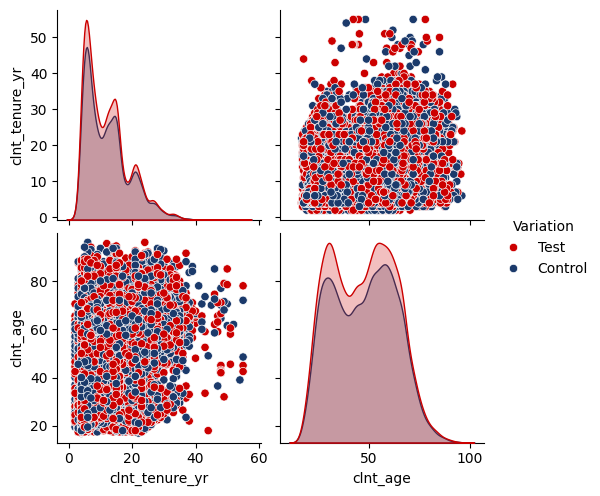

In [13]:
#Let's look at the age and tenure years between primary clients and non-primary clients
g = sns.pairplot(df1[["clnt_tenure_yr", 'clnt_age','Variation']], hue='Variation',
                 palette={'Control': '#1B3A6B', 'Test': '#CC0000'})
g.savefig('../figures/pairplot_demographics.png', dpi=150, bbox_inches='tight')


The pairplot shows **no meaningful demographic gap** between Control and Test. Mean age is 47.5 (Control) vs 47.2 (Test) and mean tenure 12.1 vs 12.0 years — differences well within noise, the only visible difference is the higher scale frequency for the Test group indicating the size of this group is bigger than Control. Within each group there is **no clear age–tenure trend**: older clients are not systematically more or less tenured.

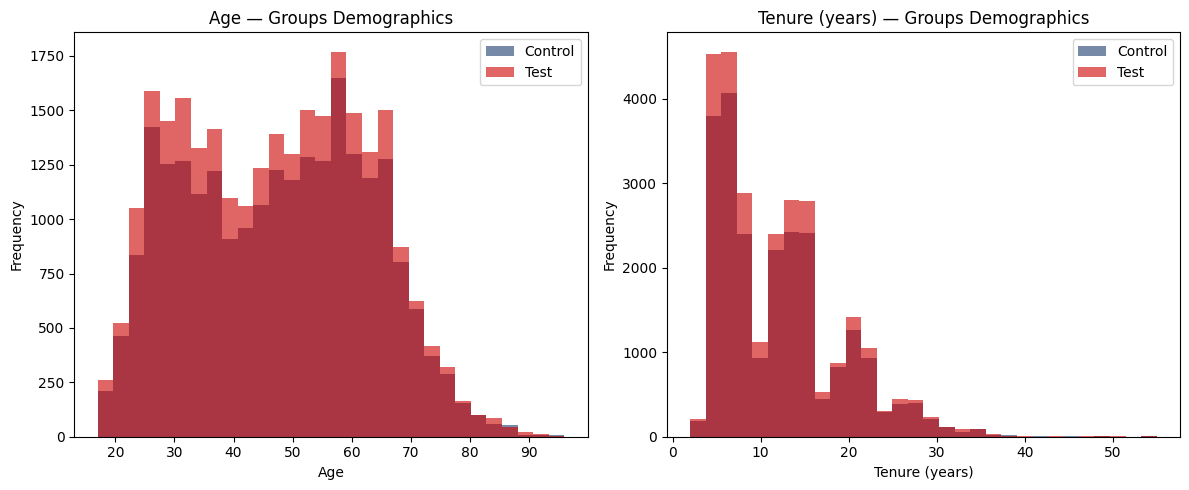

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, label, ax in zip(
    ['clnt_age', 'clnt_tenure_yr'],
    ['Age', 'Tenure (years)'],
    axes
):
    _color_map = {'#1B3A6B': '#1B3A6B', 'Control': '#1B3A6B', 'Test': '#CC0000'}
    for group, grp_df in df1.groupby('Variation'):
        grp_df[col].plot.hist(ax=ax, alpha=0.6, bins=30, label=group, color=_color_map.get(group, '#6B7280'))
    ax.set_title(f'{label} — Groups Demographics')
    ax.set_xlabel(label)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/AgeTenure_demographics.png', dpi=150)
plt.show()

Test shows taller bars simply because it is the larger group (Test ≈ 26,961 vs Control ≈ 23,527). Once that size gap is set aside, the **shapes** of the age and tenure distributions are comparable across groups.

In [16]:
#wLets add the Variation = no-data to the Control group.
df['group'] = np.where(
    df['Variation'].isin(['no_data','Control']),
    'Control', 'Test')
df.group.unique()

<StringArray>
['Test', 'Control']
Length: 2, dtype: str

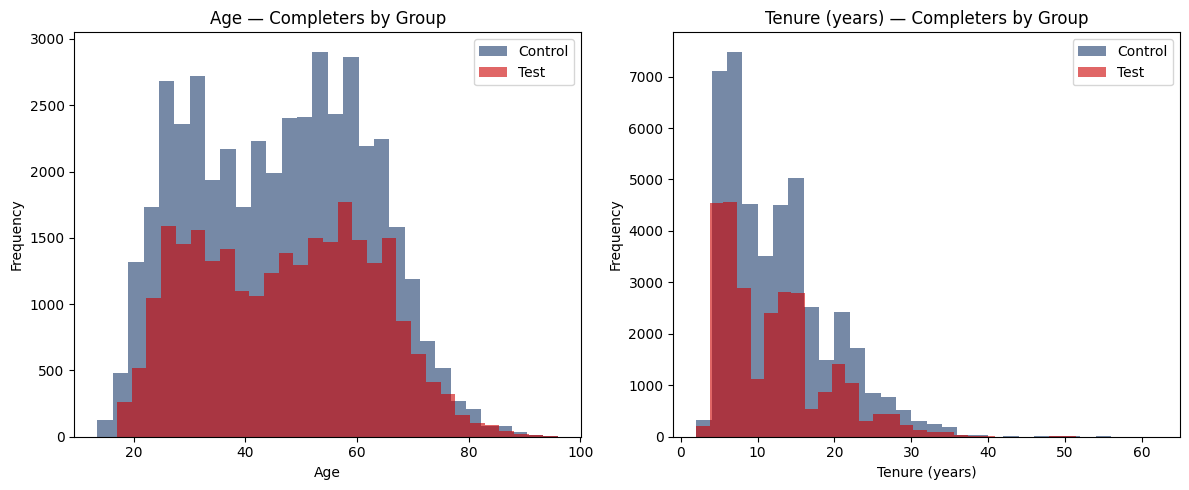

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, label, ax in zip(
    ['clnt_age', 'clnt_tenure_yr'],
    ['Age', 'Tenure (years)'],
    axes
):
    _color_map = {'#1B3A6B': '#1B3A6B', 'Control': '#1B3A6B', 'Test': '#CC0000'}
    for group, grp_df in df.groupby('group'):
        grp_df[col].plot.hist(ax=ax, alpha=0.6, bins=30, label=group, color=_color_map.get(group, '#6B7280'))
    ax.set_title(f'{label} — Completers by Group')
    ax.set_xlabel(label)
    ax.legend()

plt.tight_layout()
#plt.savefig('../figures/completers_demographics.png', dpi=150)
plt.show()

Folding the `no_data` clients into Control would make the Control group *larger than Test* and mix in clients whose assignment is unknown. To keep the comparison clean we **exclude `no_data`** and analyse only explicitly assigned Control / Test clients.

gendr,F,M,U,X
Variation,,,,
Control,32.061036,33.875972,34.062991,0.000000
Test,32.328178,33.296243,34.368161,0.007418


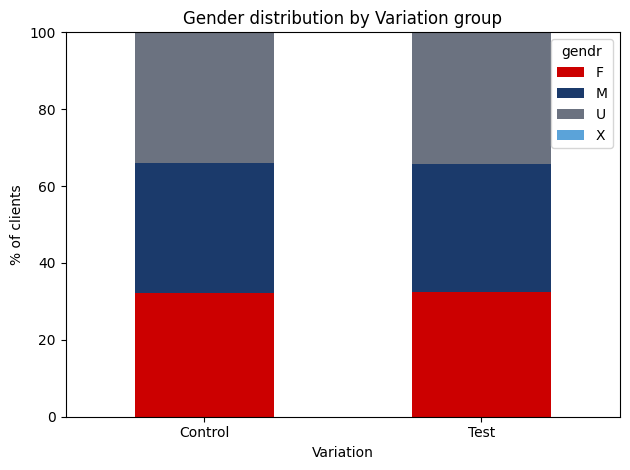

In [34]:
# Frequency table
x_gendr_pgroup = pd.crosstab(df1['Variation'], df1['gendr'], normalize='index') * 100
display(x_gendr_pgroup)

gender_colors = {'F': '#CC0000', 'M': '#1B3A6B', 'U': '#6B7280', 'X': '#5BA3D9'}
bar_colors = [gender_colors.get(col, '#6B7280') for col in x_gendr_pgroup.columns]

x_gendr_pgroup.plot(kind="bar", stacked=True, color=bar_colors);
plt.ylabel('% of clients')
plt.title('Gender distribution by Variation group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/genderDistribution.png', dpi=150)

In [22]:

display(df1.groupby('Variation')[['clnt_age', 'clnt_tenure_yr']].describe().round(2))
print('__________')


clnt_age                                             clnt_tenure_yr  \
             count   mean    std   min   25%   50%   75%   max          count   
Variation                                                                       
Control    23527.0  47.50  15.52  17.0  33.5  48.5  60.0  96.0        23527.0   
Test       26961.0  47.16  15.51  17.0  33.5  47.5  59.5  96.0        26961.0   

                                                    
            mean   std  min  25%   50%   75%   max  
Variation                                           
Control    12.09  6.88  2.0  6.0  11.0  16.0  55.0  
Test       11.98  6.84  2.0  6.0  11.0  15.0  55.0

__________


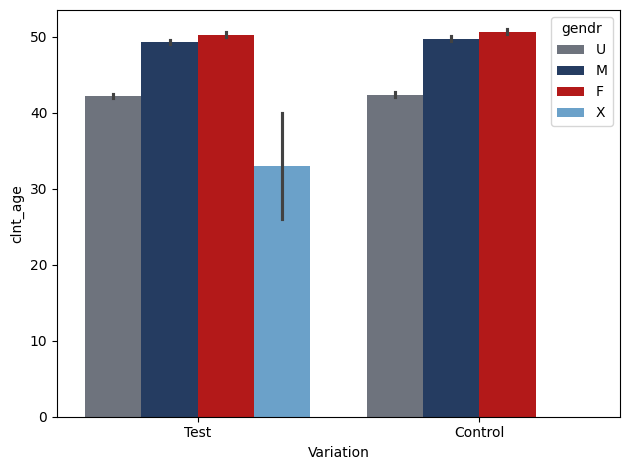

In [24]:
# Plotting a bar plot to visualize the average 'Age' for each variation group  of the Primary clients vs. Non-primary clients.
palette = {'F': '#CC0000', 'M': '#1B3A6B', 'U': '#6B7280', 'X': '#5BA3D9'}

sns.barplot(data=df1, x='Variation', y='clnt_age', palette=palette, hue='gendr', legend=True);



plt.tight_layout()


**Gender distribution — age**

Average age is **near-identical between Control and Test within every gender** (e.g. Female 50.6 vs 50.2, Male 49.7 vs 49.3), so in terms of gender the test study has a fair comparison — the key balance result.

On the gender levels themselves: Female are similar in age, but **Unknown-gender (`U`) clients are markedly younger (~42)** and `X` is a negligible handful. The gender `U` is the *youngest* segment, by roughly 8 years.

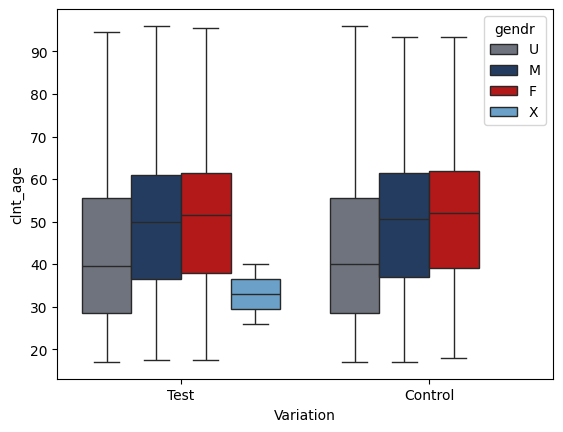

In [28]:
# 2.1 Plot a box plot for 'client age', categorized by 'gender'.
# This will help visualize the central tendencies and spreads for group.
palette = {'F': '#CC0000', 'M': '#1B3A6B', 'U': '#6B7280', 'X': '#5BA3D9'}
sns.boxplot(data=df1, x='Variation', y='clnt_age', palette=palette, hue='gendr', legend=True)
plt.savefig('../figures/genderDistribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Age — box plot by group and gender**

The age distribution is symmetric and consistent across Control and Test for each gender. Medians sit around 47–48 years and the inter-quartile ranges overlap almost perfectly — age is balanced between groups.

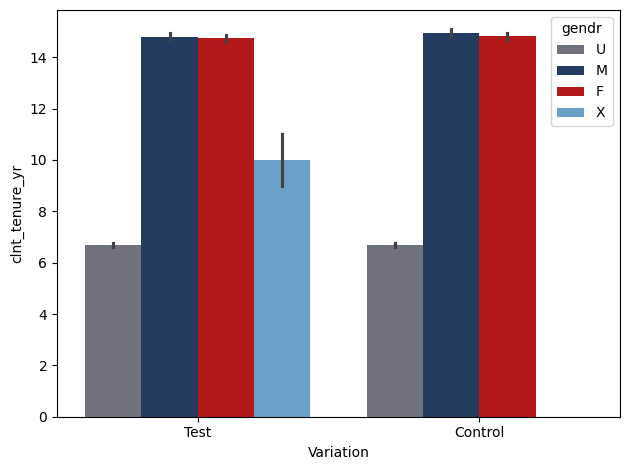

In [30]:
# Plotting a bar plot to visualize the average 'Tenure years' for each variation group  of the Primary clients vs. Non-primary clients.
palette = {'F': '#CC0000', 'M': '#1B3A6B', 'U': '#6B7280', 'X': '#5BA3D9'}


sns.barplot(data=df1, x='Variation', y='clnt_tenure_yr', palette=palette, hue='gendr', legend=True);


plt.tight_layout()


**Tenure — by group and gender**

Average tenure is essentially identical between Control and Test group across gender categories, with matched spread (std ≈ 6.8–6.9 yrs). Client seniority — a proxy for platform familiarity — is therefore balanced and unlikely to bias the completion-rate comparison.

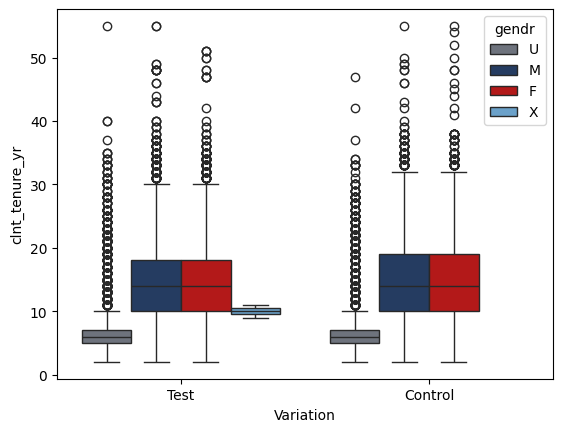

In [33]:
# 2.1 Plot a box plot for 'client age', categorized by 'gender'.
# This will help visualize the central tendencies and spreads for group.
palette = {'F': '#CC0000', 'M': '#1B3A6B', 'U': '#6B7280', 'X': '#5BA3D9'}

sns.boxplot(data=df1, x='Variation', y='clnt_tenure_yr', palette=palette, hue='gendr', legend=True)
plt.savefig('../figures/TenureDistribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Balance check passed:** age, tenure and gender are all comparable between Control and Test, so KPI differences can be attributed to the design rather than to group composition.

⚠️ *Scope caveat:* restricting KPIs to **Female + Male only** would drop the `U` (Unknown) clients — but `U` is the *largest* single gender category (~34% of clients) and skews younger, so excluding it would silently remove a third of the sample. The only group safe to drop is **`X`** (≈0.0–0.01%). Best approach for all KPIs comparison is keeping **F, M and U**, excluding only `X`.